# Google Cloud Vision API: Web Detection Interactive Tutorial
## Reverse Image Search, Web Entities, and Similar Products on GCP

This interactive Colab notebook demonstrates how to use Google Cloud Vision API's **Web Detection (`WEB_DETECTION`)** feature to perform reverse image search, discover matching web pages, extract web entities, and identify visually similar objects across the public internet.

### What this notebook covers:
1. **Environment Setup & Authentication**: Connect to Google Cloud and install the official client library.
2. **Official Tutorial Sample**: Run Web Detection against `gs://cloud-samples-data/vision/web/carnaval.jpeg`.
3. **Interactive Testing with Custom Images**: Upload your own industrial product/spare part photo or test with any web URL.
4. **Structured Output Visualization**: Parse Best Guess Labels, Web Entities, Matching Web Pages, and Visually Similar Images with clean formatted tables.
5. **Agentic Integration Overview**: How this capability plugs into the **Gemini Enterprise Agent Platform** for automated spare part identification.

In [1]:
# 1. Install Google Cloud Vision client library and visualization helpers
!pip install --quiet google-cloud-vision ipython pillow matplotlib requests tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.2/542.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 43.9 MB/s eta 0:00:00


### 2. Google Cloud Authentication & Project Setup

Run the cell below to authenticate your Google Cloud account in Google Colab and set your active Project ID.

> **Note**: Make sure the **Cloud Vision API** is enabled in your Google Cloud Project:
> [Enable Cloud Vision API in GCP Console](https://console.cloud.google.com/flows/enableapi?apiid=vision.googleapis.com)

In [7]:
import os
from google.colab import auth

# Authenticate user session
auth.authenticate_user()

# Specify your GCP Project ID
PROJECT_ID = "tanlingyi-814-20240515105953"  # @param {type:"string"}
os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID

!gcloud config set project {PROJECT_ID}
print(f"Authenticated successfully with GCP Project: {PROJECT_ID}")

[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].
Authenticated successfully with GCP Project: tanlingyi-814-20240515105953


### 3. Define Cloud Vision Web Detection Helper Functions

The following cell creates:
* `detect_web_from_uri(uri)`: Executes Web Detection on an image hosted on Google Cloud Storage (`gs://...`) or public HTTP/HTTPS URL.
* `detect_web_from_file(path)`: Reads local image bytes (e.g. uploaded by a technician) and sends them to the API.
* `display_web_results(annotations, image_path_or_uri)`: Renders formatted summary tables of:
  * **Best Guess Labels**
  * **Web Entities** (with relevance/confidence scores)
  * **Pages with Matching Images** (with page titles and URLs)
  * **Visual Matches** (Full, Partial, and Visually Similar images)

In [11]:
from google.api_core.client_options import ClientOptions

def create_vision_client(project_id="tanlingyi-814-20240515105953"):
    """Initializes the Cloud Vision ImageAnnotatorClient with an explicit project."""
    # Force the client to use your project for quota and billing
    options = ClientOptions(quota_project_id=project_id)
    return vision.ImageAnnotatorClient(client_options=options)

In [12]:
import io
import requests
from PIL import Image as PILImage
import matplotlib.pyplot as plt
from google.cloud import vision
from tabulate import tabulate


def detect_web_from_uri(image_uri: str, max_results: int = 15):
    """Detects web annotations from a Google Cloud Storage URI (gs://...) or web URL (http://...)."""
    client = create_vision_client()
    image = vision.Image()

    if image_uri.startswith("gs://"):
        image.source.image_uri = image_uri
    else:
        # Download image bytes if given an http(s) URL
        response = requests.get(image_uri, timeout=15)
        response.raise_for_status()
        image.content = response.content

    response = client.web_detection(image=image, max_results=max_results)
    if response.error.message:
        raise RuntimeError(f"Cloud Vision API Error: {response.error.message}")
    return response.web_detection

def detect_web_from_file(image_path: str, max_results: int = 15):
    """Detects web annotations from local image bytes."""
    client = create_vision_client()
    with io.open(image_path, "rb") as image_file:
        content = image_file.read()
    image = vision.Image(content=content)

    response = client.web_detection(image=image, max_results=max_results)
    if response.error.message:
        raise RuntimeError(f"Cloud Vision API Error: {response.error.message}")
    return response.web_detection

def display_web_results(annotations, image_path_or_uri=None):
    """Renders formatted tables of web entities, matching pages, and visual matches."""
    # Render preview image
    if image_path_or_uri:
        try:
            if image_path_or_uri.startswith("http"):
                img = PILImage.open(requests.get(image_path_or_uri, stream=True, timeout=10).raw)
            elif not image_path_or_uri.startswith("gs://"):
                img = PILImage.open(image_path_or_uri)
            else:
                img = None
            if img:
                plt.figure(figsize=(5, 5))
                plt.imshow(img)
                plt.axis("off")
                plt.title("Query Image", fontsize=12)
                plt.show()
        except Exception as e:
            print(f"(Note: Could not render inline image preview: {e})")

    print("\n" + "=" * 85)
    print("🔍 GOOGLE CLOUD VISION — WEB DETECTION RESULTS")
    print("=" * 85)

    # 1. Best Guess Labels
    if annotations.best_guess_labels:
        print("\n📌 BEST GUESS LABELS:")
        for label in annotations.best_guess_labels:
            print(f"  • {label.label} (language: {label.language_code})")

    # 2. Web Entities
    if annotations.web_entities:
        print("\n🏷️  TOP WEB ENTITIES (Identified concepts & Knowledge Graph labels):")
        entity_rows = [
            [e.entity_id, e.description, f"{e.score:.4f}"]
            for e in annotations.web_entities
            if e.description
        ]
        if entity_rows:
            print(tabulate(entity_rows[:10], headers=["Entity ID", "Description", "Confidence Score"], tablefmt="github"))

    # 3. Pages with Matching Images
    if annotations.pages_with_matching_images:
        print(f"\n🌐 PAGES WITH MATCHING IMAGES ({len(annotations.pages_with_matching_images)} total found):")
        page_rows = []
        for p in annotations.pages_with_matching_images[:10]:
            title = p.page_title.strip() if p.page_title else "(No title)"
            page_rows.append([title[:45], p.url[:65]])
        print(tabulate(page_rows, headers=["Page Title", "Page URL"], tablefmt="github"))

    # 4. Matching Image Assets
    full_count = len(annotations.full_matching_images) if annotations.full_matching_images else 0
    partial_count = len(annotations.partial_matching_images) if annotations.partial_matching_images else 0
    similar_count = len(annotations.visually_similar_images) if annotations.visually_similar_images else 0

    print(f"\n🖼️  MATCHING IMAGE ASSETS:")
    print(f"  • Full Matching Images:     {full_count}")
    print(f"  • Partial Matching Images:  {partial_count}")
    print(f"  • Visually Similar Images:  {similar_count}")

    if annotations.visually_similar_images:
        print("\nSample Visually Similar Image URLs:")
        for img in annotations.visually_similar_images[:5]:
            print(f"  • {img.url}")
    print("=" * 85)

### 4. Test with the Official Google Sample

Let's execute Web Detection on the tutorial image: `gs://cloud-samples-data/vision/web/carnaval.jpeg`.
Notice how the API returns:
* Best guess label (identifying the Carnaval celebration).
* Web entities (identifying "Carnival", "Festival", geographic locations).
* Matching web pages where this exact image appears.
* Visually similar image URLs.

In [13]:
sample_gcs_uri = "gs://cloud-samples-data/vision/web/carnaval.jpeg"
print(f"Submitting official tutorial image to Cloud Vision API: {sample_gcs_uri}...")

Submitting official tutorial image to Cloud Vision API: gs://cloud-samples-data/vision/web/carnaval.jpeg...


In [14]:
annotations = detect_web_from_uri(sample_gcs_uri)
display_web_results(annotations, sample_gcs_uri)


🔍 GOOGLE CLOUD VISION — WEB DETECTION RESULTS

📌 BEST GUESS LABELS:
  • carnival in brazil (language: en)

🏷️  TOP WEB ENTITIES (Identified concepts & Knowledge Graph labels):
| Entity ID     | Description                        |   Confidence Score |
|---------------|------------------------------------|--------------------|
| /m/06gmr      | Rio de Janeiro                     |             1.281  |
| /m/02p7_j8    | Rio Carnival                       |             1.0666 |
| /m/04cx88     | Brazilian Carnival                 |             1.0589 |
| /m/09l9f      | Carnival                           |             0.8978 |
| /g/11x0mzgw1x | Brazil Tours                       |             0.677  |
| /m/05_5y77    | Sambadrome                         |             0.6618 |
| /m/05m_9_s    | Carnival of Santa Cruz de Tenerife |             0.6288 |
| /m/014dsx     | Travel                             |             0.486  |
| /m/063r3      | Parade                             |         

### 5. Test with Your Own Product / Spare Part Image

Test how Web Detection works on your own products or automatic door spare parts.

You have two convenient options below:
* **Option A**: Upload an image directly from your local computer (e.g. a photo of a motor, sensor, or belt).
* **Option B**: Provide a public web image URL or a Cloud Storage URI (`gs://...`).

Select and upload an image file (PNG / JPEG) of a spare part or product:


Saving clker-free-vector-images-padlock-308589_1920.png to clker-free-vector-images-padlock-308589_1920.png

Processing uploaded image: clker-free-vector-images-padlock-308589_1920.png...


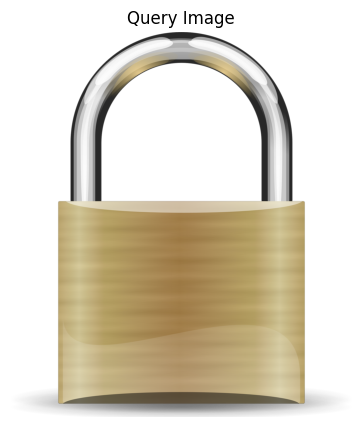


🔍 GOOGLE CLOUD VISION — WEB DETECTION RESULTS

📌 BEST GUESS LABELS:
  • schloss symbol (language: en)

🏷️  TOP WEB ENTITIES (Identified concepts & Knowledge Graph labels):
| Entity ID     | Description         |   Confidence Score |
|---------------|---------------------|--------------------|
| /m/0d5gx      | Castle              |             0.5013 |
| /g/11ms8nztbj | Wedding Chair Cover |             0.3938 |
| /m/09ddf      | Symbol              |             0.3697 |
| /g/11qh5bk72c | other               |             0.348  |
| /m/04g7d      | Language            |             0.3429 |
| /g/11spgy0dz3 | succeeding          |             0.3392 |
| /m/0jg24      | Image               |             0.3358 |
| /g/11ryz3dn2g | just                |             0.3266 |
| /m/05_7__     | Padlock             |             0.3247 |
| /g/11zjvyqgw6 | Housses-Tendances   |             0.3244 |

🌐 PAGES WITH MATCHING IMAGES (15 total found):
| Page Title                                   

In [15]:
# Option A: Upload a photo from your local computer
from google.colab import files

print("Select and upload an image file (PNG / JPEG) of a spare part or product:")
uploaded = files.upload()

if uploaded:
    local_filename = next(iter(uploaded))
    print(f"\nProcessing uploaded image: {local_filename}...")
    part_annotations = detect_web_from_file(local_filename)
    display_web_results(part_annotations, local_filename)
else:
    print("No file uploaded. You can run the next cell to test via a web URL.")

In [16]:
# Option B: Test with a public image URL or Cloud Storage URI
test_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/6/69/Electric_motor_cycle_2.jpg/640px-Electric_motor_cycle_2.jpg"  # @param {type:"string"}

if test_url:
    print(f"Submitting image URL to Cloud Vision Web Detection:\n{test_url}\n")
    url_annotations = detect_web_from_uri(test_url)
    display_web_results(url_annotations, test_url)

Submitting image URL to Cloud Vision Web Detection:
https://upload.wikimedia.org/wikipedia/commons/thumb/6/69/Electric_motor_cycle_2.jpg/640px-Electric_motor_cycle_2.jpg



HTTPError: 403 Client Error: Forbidden for url: https://upload.wikimedia.org/wikipedia/commons/thumb/6/69/Electric_motor_cycle_2.jpg/640px-Electric_motor_cycle_2.jpg

### 6. Architectural Summary & Production Next Steps

In **Project Identify**, this capability acts as the **External Web Discovery Tool**:

1. **Deterministic OCR & Cropping**: When an automatic door part photo is submitted, Cloud Vision API extracts serial numbers, brand names (e.g. Dormakaba, Besam, Geze, Record), and electrical ratings.
2. **Reverse Web Detection**: `WebDetection` searches the open web for supplier catalogs, distributor product listings, and matching image assets without requiring manual web scraping.
3. **Synthesis via Gemini Enterprise Agent Platform**:
   * **Gemini 3.5 Flash** formulates targeted text search queries using the discovered `webEntities`.
   * **Gemini 3.5 Pro** reconciles external web candidate specifications (voltage, gear tooth count, mounting flange) against the internal **Vector Search (ScaNN)** catalog to produce a verified part recommendation with full rationale and citations.
4. **End-to-End Observability**: Tool latency, confidence scores, and reasoning trajectories are automatically traced via **Agent Observability** and benchmarked via **Agent Evaluation**.